# PS1 · Task 1 — Cross-Sectional Return Prediction

Predict `ret` from firm characteristics (one row per firm). The signal is **linear and weak**
(OOS R² ≈ 0.05): the target is built as *linear(features) + large idiosyncratic noise*, so
R² ≈ 0.05 is the noise ceiling. `firm_id` is an identifier, not a feature.

**Map** — §0 setup · §1 EDA · §2 preprocessing & CV harness · §3 baseline (ridge, LOO α) ·
§4 **linear search**: {raw, interactions, poly-2, splines} × {ridge, lasso, elastic-net} ·
§5 **ensembles & boosting** · §6 bias–variance (α sweep) · §7 final → CSV · §8 conclusion.

## 0. Setup

In [10]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   PolynomialFeatures, SplineTransformer)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_score, cross_validate, RepeatedKFold

SEED = 0
np.seterr(all="ignore")   # harmless: RidgeCV's leave-one-out solver emits a divide-by-zero warning

FAST = True               # True = quick CV (5x2) while iterating; set False for final numbers (10x5)

train = pd.read_parquet("task1_training_data.parquet")
test  = pd.read_parquet("task1_testing_data.parquet")

NUM, CAT, TARGET = ["size", "value", "profit", "invest", "mom"], ["rating"], "ret"
X, y = train[NUM + CAT], train[TARGET]
print("train:", train.shape, "| test:", test.shape, "| FAST =", FAST)

train: (3500, 8) | test: (1500, 7) | FAST = True


## 1. EDA — quick look

In [11]:
display(train[NUM + [TARGET]].describe().round(3))
print("corr with ret:")
print(train[NUM].corrwith(train[TARGET]).round(3).sort_values())

,size,value,profit,invest,mom,ret
count,3500.000,3500.000,3500.000,3500.000,3500.000,3500.000
mean,-0.019,0.006,0.015,-0.006,-0.004,0.134
std,1.167,1.170,1.169,1.165,1.144,0.255
min,-3.696,-4.109,-3.750,-4.296,-3.836,-0.735
25%,-0.804,-0.787,-0.783,-0.772,-0.763,-0.034
50%,-0.024,0.011,0.022,0.015,-0.016,0.126
75%,0.760,0.817,0.816,0.762,0.731,0.301
max,3.904,4.273,4.823,3.949,4.213,1.279


corr with ret:
size     -0.128
invest   -0.071
profit    0.027
value     0.135
mom       0.143
dtype: float64


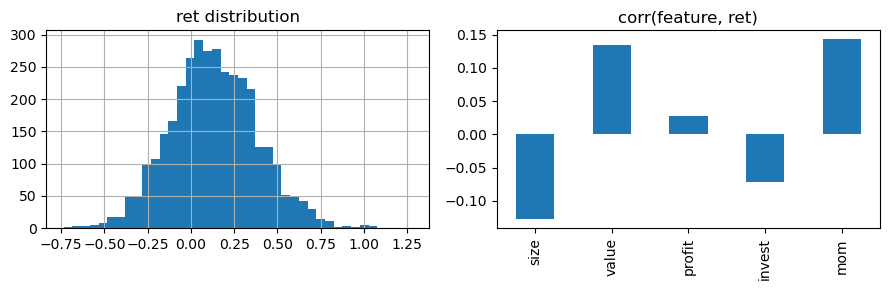

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
train[TARGET].hist(bins=40, ax=ax[0]); ax[0].set_title("ret distribution")
train[NUM].corrwith(train[TARGET]).plot.bar(ax=ax[1]); ax[1].set_title("corr(feature, ret)")
plt.tight_layout(); plt.show()

## 2. Preprocessing & CV harness

`pre` standardizes the numeric factors and one-hot encodes `rating`. `make_pre(expansion)` adds a
feature expansion to the **numeric block only**. Every experiment is scored through the same `cv`
and `score()` helper, so all numbers below are directly comparable.

In [13]:
alphas = np.logspace(-2, 3, 50)

def make_pre(expansion=None):
    # scale numerics (+ optional expansion); one-hot the rating bucket
    num_steps = [("scale", StandardScaler())]
    if expansion is not None:
        num_steps.append(("exp", expansion))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUM),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), CAT),
    ])

pre = make_pre()                       # baseline preprocessing (no expansion)
cv  = (RepeatedKFold(n_splits=5,  n_repeats=2, random_state=SEED) if FAST
       else RepeatedKFold(n_splits=10, n_repeats=5, random_state=SEED))

def score(name, estimator):
    # mean / std out-of-sample R^2 over cv (folds run in parallel)
    s = cross_val_score(estimator, X, y, cv=cv, scoring="r2", n_jobs=-1)
    return {"model": name, "cv_R2": round(s.mean(), 4), "std": round(s.std(), 4)}

## 3. Baseline — ridge with leave-one-out α

`RidgeCV` (default `cv=None`) tunes α by the closed-form **leave-one-out** — one fit, essentially free.

In [14]:
baseline = Pipeline([("pre", pre), ("ridge", RidgeCV(alphas=alphas))]).fit(X, y)
print("LOO-chosen alpha:", round(baseline.named_steps["ridge"].alpha_, 2))
print(score("baseline ridge", baseline))

LOO-chosen alpha: 152.64
{'model': 'baseline ridge', 'cv_R2': 0.0539, 'std': 0.013}


## 4. Model search — linear: expansions × regularizers

The grid: each **feature expansion** crossed with each **regularized linear head**.
`RidgeCV` / `LassoCV` / `ElasticNetCV` each tune their own penalty internally.

In [21]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)   # lasso/EN paths on expanded features

expansions = {
    "raw":          None,
    "interactions": PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    "poly-2":       PolynomialFeatures(degree=2, include_bias=False),
    "splines":      SplineTransformer(n_knots=5, degree=3),
}
heads = {
    "ridge":       RidgeCV(alphas=alphas),
    "lasso":       LassoCV(cv=5, n_jobs=1, max_iter=20000, random_state=SEED),
    "elastic-net": ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, n_jobs=1, max_iter=20000, random_state=SEED),
}

rows = []
for ename, exp in expansions.items():
    for hname, head in heads.items():
        pre_e = make_pre(clone(exp)) if exp is not None else make_pre()
        pipe  = Pipeline([("pre", pre_e), ("head", clone(head))])
        rows.append(score(f"{ename} + {hname}", pipe))

linear_results = pd.DataFrame(rows).sort_values("cv_R2", ascending=False).reset_index(drop=True)
display(linear_results)

,model,cv_R2,std
0,interactions + ridge,0.0559,0.0122
1,poly-2 + ridge,0.0551,0.0129
2,poly-2 + elastic-net,0.0546,0.0132
3,poly-2 + lasso,0.0545,0.0134
4,raw + ridge,0.0539,0.0130
5,interactions + elastic-net,0.0539,0.0113
6,interactions + lasso,0.0538,0.0114
7,raw + elastic-net,0.0534,0.0134
8,raw + lasso,0.0530,0.0131
9,splines + ridge,0.0522,0.0162


### Is the top of the grid actually better than the baseline?

The best expansion edges raw ridge by only ~0.001. The linear variants are correlated (they share
the same factors), so compare the best one to the baseline **paired on the same folds** and check the
t-statistic before believing any ranking.

In [16]:
# paired comparison on identical folds: does the poly-2 expansion beat raw ridge for real?
def fold_r2(expansion):
    pre_e = make_pre(clone(expansion)) if expansion is not None else make_pre()
    return cross_val_score(Pipeline([("pre", pre_e), ("head", RidgeCV(alphas=alphas))]),
                           X, y, cv=cv, scoring="r2", n_jobs=-1)

d = fold_r2(PolynomialFeatures(degree=2, include_bias=False)) - fold_r2(None)
t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
verdict = "within noise -> keep the simpler raw-ridge baseline" if abs(t) < 2 else "a real improvement"
print(f"poly-2 + ridge  minus  raw + ridge:  mean delta = {d.mean():+.5f}")
print(f"paired t = {t:+.2f}  (|t| > 2 ~ significant);  wins {100*(d > 0).mean():.0f}% of {len(d)} folds")
print(f"verdict: {verdict}")

poly-2 + ridge  minus  raw + ridge:  mean delta = +0.00116
paired t = +0.57  (|t| > 2 ~ significant);  wins 50% of 10 folds
verdict: within noise -> keep the simpler raw-ridge baseline


## 5. Model search — ensembles & boosting

Tree ensembles and boosting can fit nonlinearity, but on a linear + heavy-noise target they tend
to overfit. The optional `xgboost` / `lightgbm` rows run only if those packages are installed.

In [17]:
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor,
                              AdaBoostRegressor)

ensembles = {
    "random forest":      RandomForestRegressor(n_estimators=400, max_depth=6, random_state=SEED, n_jobs=1),
    "extra trees":        ExtraTreesRegressor(n_estimators=400, max_depth=6, random_state=SEED, n_jobs=1),
    "adaboost":           AdaBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED),
    "gradient boosting":  GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.03, random_state=SEED),
    "hist grad boosting": HistGradientBoostingRegressor(max_iter=400, max_depth=3, learning_rate=0.03,
                                                        l2_regularization=1.0, random_state=SEED),
}
try:
    from xgboost import XGBRegressor
    ensembles["xgboost"] = XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                        subsample=0.8, reg_lambda=1.0, random_state=SEED, n_jobs=1)
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    ensembles["lightgbm"] = LGBMRegressor(n_estimators=400, max_depth=3, learning_rate=0.03,
                                          subsample=0.8, reg_lambda=1.0, random_state=SEED, n_jobs=1, verbose=-1)
except ImportError:
    pass

rows = [score(n, Pipeline([("pre", pre), ("m", est)])) for n, est in ensembles.items()]
ensemble_results = pd.DataFrame(rows).sort_values("cv_R2", ascending=False).reset_index(drop=True)
display(ensemble_results)

,model,cv_R2,std
0,random forest,0.0475,0.0135
1,extra trees,0.0465,0.0101
2,gradient boosting,0.0449,0.0124
3,hist grad boosting,0.0385,0.0157
4,adaboost,0.0316,0.0061


### Random-forest depth sweep

Probing tree depth directly: deeper = lower bias but higher variance. On this DGP the curve
never reaches the linear models.

In [18]:
depths = [3, 4, 5, 6, 8, 12]
rf_sweep = pd.DataFrame([
    score(f"RF depth={d}", Pipeline([("pre", pre),
          ("m", RandomForestRegressor(n_estimators=300, max_depth=d, random_state=SEED, n_jobs=1))]))
    for d in depths
])
display(rf_sweep)

,model,cv_R2,std
0,RF depth=3,0.0401,0.0107
1,RF depth=4,0.0438,0.0118
2,RF depth=5,0.0463,0.0127
3,RF depth=6,0.0472,0.0139
4,RF depth=8,0.0454,0.0145
5,RF depth=12,0.0388,0.0163


## 6. Bias–variance view (α sweep)

The clearest picture of the tradeoff: as α grows the model moves from low-bias/high-variance
(overfit) to high-bias/low-variance (underfit). The train−CV gap is the variance.

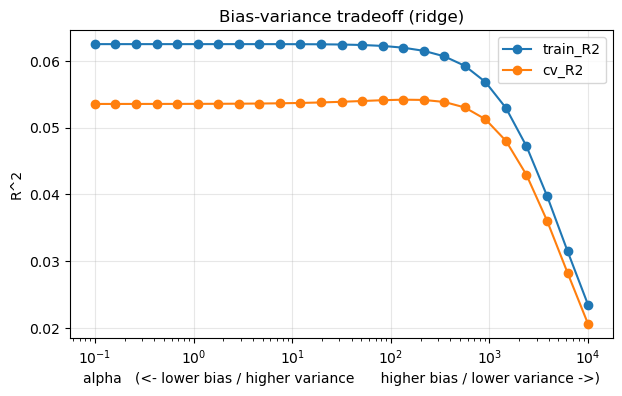

best CV alpha = 133.35   CV R^2 = +0.0542


In [19]:
from sklearn.linear_model import Ridge
sweep = np.logspace(-1, 4, 25)
rows = []
for a in sweep:
    out = cross_validate(Pipeline([("pre", pre), ("ridge", Ridge(alpha=a))]),
                         X, y, cv=cv, scoring="r2", return_train_score=True, n_jobs=-1)
    rows.append((a, out["train_score"].mean(), out["test_score"].mean()))
sweep_df = pd.DataFrame(rows, columns=["alpha", "train_R2", "cv_R2"]).set_index("alpha")

ax = sweep_df.plot(logx=True, marker="o", figsize=(7, 4))
ax.set_xlabel("alpha   (<- lower bias / higher variance      higher bias / lower variance ->)")
ax.set_ylabel("R^2"); ax.set_title("Bias-variance tradeoff (ridge)"); ax.grid(alpha=.3); plt.show()
print(f"best CV alpha = {sweep_df.cv_R2.idxmax():.2f}   CV R^2 = {sweep_df.cv_R2.max():+.4f}")

## 7. Final model → `task1_predictions.csv`

All linear variants tie at ≈0.05 and the nonlinear models do worse, so we take the **simplest**
top model — ridge — and refit it on all training data (parsimony / Occam's razor).

In [20]:
final = Pipeline([("pre", pre), ("ridge", RidgeCV(alphas=alphas))]).fit(X, y)

pred = pd.DataFrame({"firm_id": test["firm_id"], "y_hat": final.predict(test[NUM + CAT])})
pred.to_csv("task1_predictions.csv", index=False)

assert list(pred.columns) == ["firm_id", "y_hat"]
assert len(pred) == len(test) and pred["firm_id"].is_unique and pred["y_hat"].notna().all()
print("wrote task1_predictions.csv", pred.shape)
print(f"pred mean {pred.y_hat.mean():+.4f} (train {y.mean():+.4f}) | "
      f"pred std {pred.y_hat.std():.4f} (train {y.std():.4f})")
pred.head()

wrote task1_predictions.csv (1500, 2)
pred mean +0.1331 (train +0.1343) | pred std 0.0610 (train 0.2553)


,firm_id,y_hat
0,1501,0.130665
1,2586,0.062044
2,2653,0.154684
3,1055,0.071389
4,705,0.213922


## 8. Conclusion

- **Best model: ridge with leave-one-out α** (≈ OLS; lasso and elastic-net tie it). OOS R² ≈ **0.054**.
- **Feature expansions don't *significantly* help** — poly-2 / interactions edge `raw` by ~0.001 in the
  mean, but a paired test (t ≈ 0.7, see §4) says that's noise; splines / lasso / elastic-net don't help
  either. The factors enter linearly.
- **Ensembles & boosting underperform** (≈ 0.03–0.047): with a linear + heavy-noise target they fit
  noise. Deeper RF lowers bias but peaks (~depth 6) well below the linear models.
- **Why**: the target is *linear(features) + large idiosyncratic noise*, so R² ≈ 0.05 is the **noise
  ceiling**, not a modelling shortfall — the right move is the simplest model that reaches it.
- **Submission**: `task1_predictions.csv`, from the refit ridge.